# Data Augmentation

In this lab, you will develop a data augmentation.

In [17]:
import tensorflow as tf
tf.config.list_physical_devices('mps')

[]

In [18]:
# portions of this lab were taken from Deep Learning with Python

import glob
import os
import random
import shutil

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import *

import matplotlib.pyplot as plt
%matplotlib inline

### Extracting Train.zip in Google Drive

In [28]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

# --- Paths ---
DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_DIR = os.path.join(DRIVE_ROOT, "train")
TRAIN_ZIP = os.path.join(DRIVE_ROOT, "train.zip")

# --- Check if train folder exists ---
if os.path.isdir(TRAIN_DIR):
    print(f"✅ 'train' folder already exists at:\n{TRAIN_DIR}")

else:
    print("⚠️ 'train' folder not found.")

    # --- Check if zip exists ---
    if os.path.isfile(TRAIN_ZIP):
        print(f"📦 Found train.zip at:\n{TRAIN_ZIP}")
        print("🔄 Extracting...")

        with zipfile.ZipFile(TRAIN_ZIP, 'r') as zip_ref:
            zip_ref.extractall(DRIVE_ROOT)

        print("✅ Extraction complete.")

        # Verify extraction
        if os.path.isdir(TRAIN_DIR):
            print(f"🎉 'train' folder is now available at:\n{TRAIN_DIR}")
        else:
            print("⚠️ Extraction finished but 'train' folder not found. Check zip structure.")

    else:
        raise FileNotFoundError(
            "❌ Neither 'train' folder nor 'train.zip' found in MyDrive.\n"
            "Please upload one of them."
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 'train' folder already exists at:
/content/drive/MyDrive/train


In [29]:
# train.zip
NSAMPLES = 1000

dataset_dir = "/content/drive/MyDrive/"

train_dir = dataset_dir + "/train"

train_dogs = glob.glob(train_dir + "/dog*.*")
train_cats = glob.glob(train_dir + "/cat*.*")

sampled_train_dir = dataset_dir + "/s_train"
sampled_valid_dir = dataset_dir + "/s_valid"
sampled_test_dir = dataset_dir + "/s_test"

try:
    shutil.rmtree(sampled_train_dir)
    shutil.rmtree(sampled_valid_dir)
    shutil.rmtree(sampled_test_dir)
except:
    pass

os.mkdir(sampled_train_dir)
os.mkdir(sampled_valid_dir)
os.mkdir(sampled_test_dir)

os.mkdir(sampled_train_dir + "/dogs")
os.mkdir(sampled_train_dir + "/cats")

os.mkdir(sampled_valid_dir + "/dogs")
os.mkdir(sampled_valid_dir + "/cats")

os.mkdir(sampled_test_dir + "/dogs")
os.mkdir(sampled_test_dir + "/cats")

random.shuffle(train_dogs)
random.shuffle(train_cats)

for fn in train_dogs[0:NSAMPLES]:
    src = fn
    dst = sampled_train_dir + "/dogs/" + os.path.split(src)[-1]
    shutil.copyfile(src, dst)

for fn in train_cats[0:NSAMPLES]:
    src = fn
    dst = sampled_train_dir + "/cats/" + os.path.split(src)[-1]
    shutil.copyfile(src, dst)

for fn in train_dogs[NSAMPLES:NSAMPLES + NSAMPLES//2]:
    src = fn
    dst = sampled_valid_dir + "/dogs/" + os.path.split(src)[-1]
    shutil.copyfile(src, dst)

for fn in train_cats[NSAMPLES:NSAMPLES + NSAMPLES//2]:
    src = fn
    dst = sampled_valid_dir + "/cats/" + os.path.split(src)[-1]
    shutil.copyfile(src, dst)

print("... generated directories s_train, s_valid and s_test")

... generated directories s_train, s_valid and s_test


Now you will create a model to learn now to differentiate between cats and dogs.

In [30]:
def get_model():
    x = x_in = Input((150,150,3), name="input")
    x = Conv2D(32, (5,5), padding="valid",  name="fe0")(x)
    x = BatchNormalization()(x)
    x = Activation("gelu", name="r0")(x)
    x = MaxPooling2D(2,2,name="mp0")(x)
    x = Conv2D(64, (3,3), padding="valid", name="fe1")(x)
    x = BatchNormalization()(x)
    x = Activation("gelu", name="r1")(x)
    x = MaxPooling2D(2,2,name="mp1")(x)
    x = Conv2D(128, (3,3), padding="valid", name="fe2")(x)
    x = BatchNormalization()(x)
    x = Activation("gelu", name="r2")(x)
    x = MaxPooling2D(2,2,name="mp2")(x)
    x = Conv2D(128, (3,3), padding="valid", name="fe3")(x)
    x = BatchNormalization()(x)
    x = Activation("gelu", name="r3")(x)
    x = MaxPooling2D(2,2,name="mp3")(x)
    x = Flatten(name="fl")(x)
    x = Dropout(0.5, name="d5")(x)
    x = Dense(512, name="d1", activation="swish")(x)
    x = Dense(1, name="d2")(x)
    x = Activation("sigmoid", name="s1")(x)
    m = Model(inputs=x_in, outputs=x, name='mymodel')
    m.summary()

    return m

adam = tf.keras.optimizers.Adam(learning_rate=0.001)
# adam = Adam(learning_rate=0.001)

model = get_model()
model.compile(loss="binary_crossentropy", optimizer=adam, metrics=["acc"])

Model: "mymodel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe0 (Conv2D)                    │ (None, 146, 146, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 146, 146, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r0 (Activation)                 │ (None, 146, 146, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp0 (MaxPooling2D)              │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe1 (Conv2D)                    │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 71, 71, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r1 (Activation)                 │ (None, 71, 71, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp1 (MaxPooling2D)              │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe2 (Conv2D)                    │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 33, 33, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r2 (Activation)                 │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp2 (MaxPooling2D)              │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe3 (Conv2D)                    │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r3 (Activation)                 │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp3 (MaxPooling2D)              │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fl (Flatten)                    │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d5 (Dropout)                    │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dense)                      │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 1)              │           513 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1 (Activation)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,456,065 (13.18 MB)

 Trainable params: 3,455,361 (13.18 MB)

 Non-trainable params: 704 (2.75 KB)

In [31]:
print(model.get_layer('d1').get_weights()[0].shape, model.get_layer('d1').get_weights()[1].shape)

(6272, 512) (512,)


In [32]:
# [0] : weights, [1] : bias
import numpy as np
for layer in model.layers:
    if isinstance(layer, Dense) or isinstance(layer, Conv2D):
        print(layer.name, np.min(layer.get_weights()[0]), np.max(layer.get_weights()[0]))

fe0 -0.08276351 0.082807496
fe1 -0.083331406 0.083328344
fe2 -0.05892524 0.05892547
fe3 -0.051030017 0.05103089
d1 -0.029739406 0.029739419
d2 -0.108094655 0.10786391


 Now you will create an image generator and train this set.

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = "/content/drive/MyDrive/"

train_dir = dataset_dir + "/train"

train_dogs = glob.glob(train_dir + "/dog*.*")
train_cats = glob.glob(train_dir + "/cat*.*")

sampled_train_dir = dataset_dir + "/s_train"
sampled_valid_dir = dataset_dir + "/s_valid"
sampled_test_dir = dataset_dir + "/s_test"

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# sample_train_dir = 'dogs' + 'cats'

train_generator = train_datagen.flow_from_directory(
    sampled_train_dir,
    target_size=(150,150),
    batch_size=100,
    class_mode="binary")

valid_generator = valid_datagen.flow_from_directory(
    sampled_valid_dir,
    target_size=(150,150),
    batch_size=100,
    class_mode="binary")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In order for you to look at the generator, lets print the shapes of what it generates.

data_batch: (100, 150, 150, 3)
labels_batch: (100,)
labels: [0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0.
 0. 1. 0. 0.]
[[[0.79215693 0.67058825 0.49803925]
  [0.7803922  0.65882355 0.48627454]
  [0.7803922  0.65882355 0.48627454]
  ...
  [0.61960787 0.7803922  0.6156863 ]
  [0.854902   0.9725491  0.87843144]
  [0.89019614 0.9843138  0.9215687 ]]

 [[0.79215693 0.67058825 0.49803925]
  [0.7843138  0.6627451  0.4901961 ]
  [0.78823537 0.6666667  0.49411768]
  ...
  [0.63529414 0.73333335 0.6509804 ]
  [0.9215687  0.9725491  1.        ]
  [0.909804   0.94117653 1.        ]]

 [[0.7960785  0.6745098  0.5019608 ]
  [0.79215693 0.67058825 0.49803925]
  [0.8000001  0.6784314  0.5058824 ]
  ...
  [0.8352942  0.86274517 0.7294118 ]
  [0.9725491  0.9725

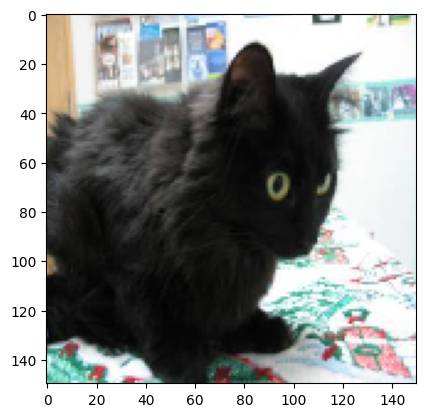

In [34]:
for data_batch, labels_batch in train_generator:
    print("data_batch:", data_batch.shape)
    print("labels_batch:", labels_batch.shape)
    print("labels:", labels_batch)
    print(data_batch[0])
    plt.imshow(data_batch[0])
    plt.show()
    break

In [35]:
history = model.fit(
    train_generator,
    steps_per_epoch=2*NSAMPLES//100, # number of times it executes until it declares epoch is over.
    epochs=30,
    validation_data=valid_generator,
    validation_steps=NSAMPLES//100)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 327ms/step - acc: 0.5503 - loss: 1.9603 - val_acc: 0.5000 - val_loss: 0.8138
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - acc: 0.5985 - loss: 0.6507 - val_acc: 0.5000 - val_loss: 0.7732
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - acc: 0.6934 - loss: 0.5800 - val_acc: 0.5000 - val_loss: 0.7742
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step - acc: 0.7093 - loss: 0.5596 - val_acc: 0.5000 - val_loss: 0.7233
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - acc: 0.7719 - loss: 0.4815 - val_acc: 0.5000 - val_loss: 1.1551
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - acc: 0.7691 - loss: 0.4622 - val_acc: 0.5000 - val_loss: 0.7568
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - acc: 0.8180 - loss: 0.3831 - val_acc: 0.5000 - val_loss: 1.1996
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - acc: 0.8444 - loss: 0.3520 - val_acc: 0.5040 - val_loss: 0.7649
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - a

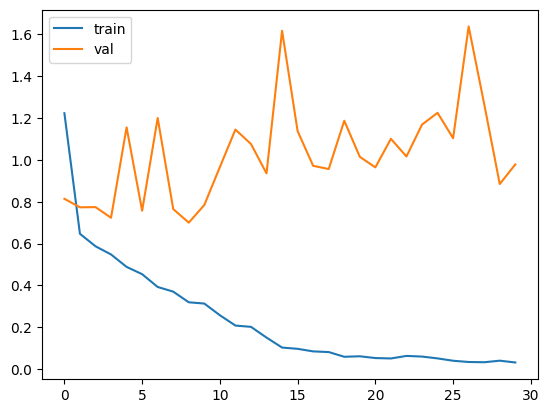

In [36]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

Not very good for the effort we did. We can try to use data augmentation by rotating, shifting, fliping, and shearing the image.

In [37]:
# shear = x = 1, y = 1.2
datagen = ImageDataGenerator(
    rotation_range=40, # between 0 and 180 degrees
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode="nearest")

/content/drive/MyDrive//train/dog.1479.jpg


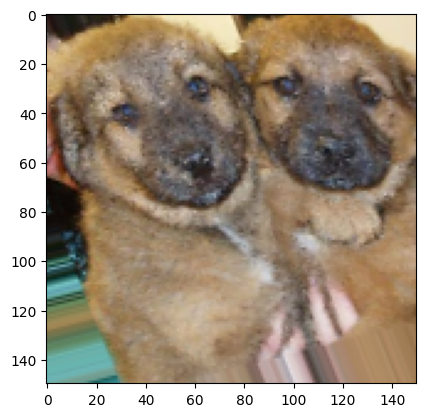

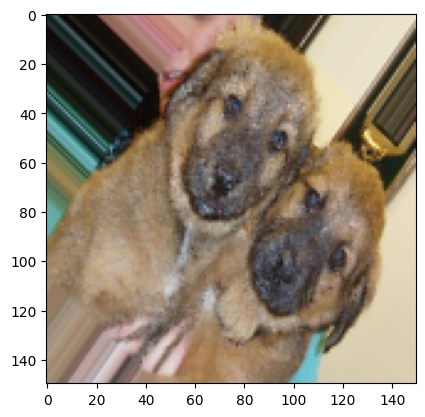

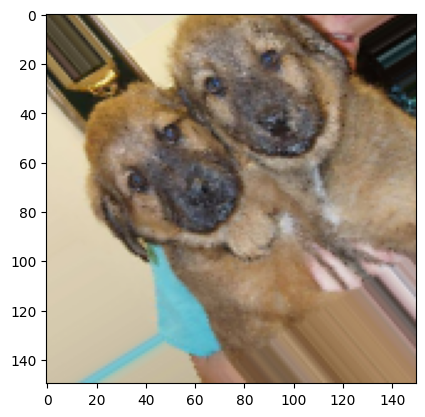

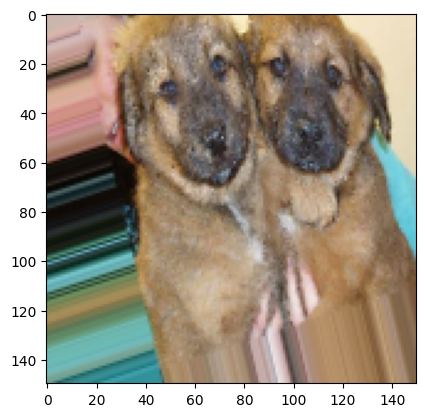

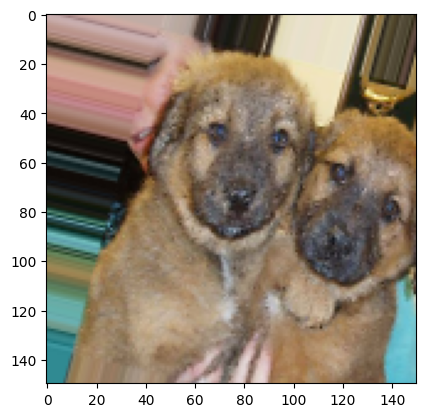

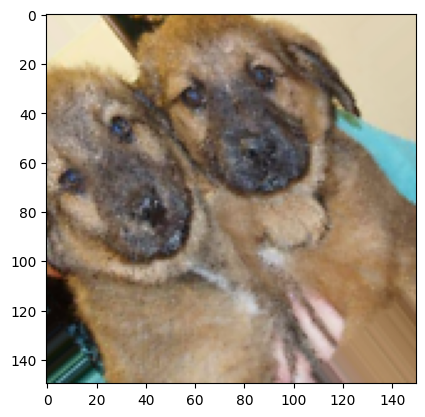

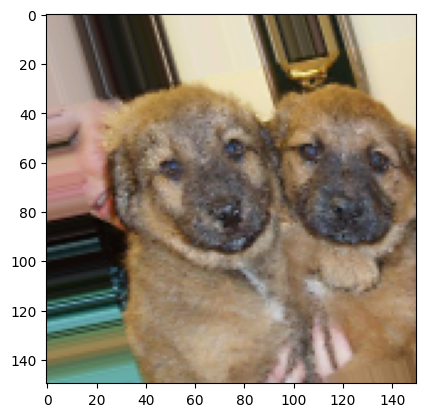

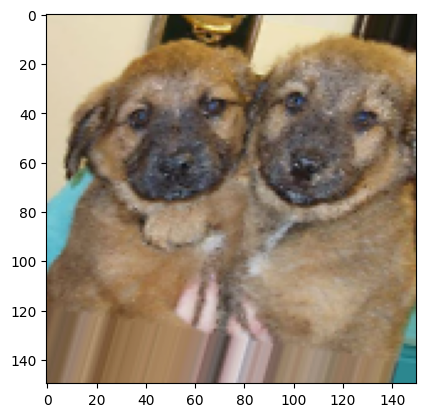

In [38]:
# let's see some of images

from tensorflow.keras.preprocessing import image

fname = train_dogs[0]

img = image.load_img(fname, target_size=(150, 150))

plt.imshow(img)
print(fname)

x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 8 == 0:
        break
plt.show()

Let's see now if we can get better result.

In [39]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    sampled_train_dir,
    target_size=(150,150),
    batch_size=100,
    class_mode="binary")

valid_generator = valid_datagen.flow_from_directory(
    sampled_valid_dir,
    target_size=(150,150),
    batch_size=100,
    class_mode="binary")

adam = tf.optimizers.Adam(learning_rate=0.0003 )

model = get_model()
model.compile(loss="binary_crossentropy", optimizer=adam, metrics=["acc"])

history = model.fit(
    train_generator,
    steps_per_epoch=2*NSAMPLES//100, # number of times it executes until it declares epoch is over.
    epochs=10,
    validation_data=valid_generator,
    validation_steps=NSAMPLES//100)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "mymodel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe0 (Conv2D)                    │ (None, 146, 146, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 146, 146, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r0 (Activation)                 │ (None, 146, 146, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp0 (MaxPooling2D)              │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe1 (Conv2D)                    │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 71, 71, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r1 (Activation)                 │ (None, 71, 71, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp1 (MaxPooling2D)              │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe2 (Conv2D)                    │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 33, 33, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r2 (Activation)                 │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp2 (MaxPooling2D)              │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fe3 (Conv2D)                    │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ r3 (Activation)                 │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp3 (MaxPooling2D)              │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fl (Flatten)                    │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d5 (Dropout)                    │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dense)                      │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 1)              │           513 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1 (Activation)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,456,065 (13.18 MB)

 Trainable params: 3,455,361 (13.18 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 559ms/step - acc: 0.5086 - loss: 2.2673 - val_acc: 0.5000 - val_loss: 0.7660
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - acc: 0.5323 - loss: 0.7375 - val_acc: 0.5000 - val_loss: 0.8126
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - acc: 0.5715 - loss: 0.6682 - val_acc: 0.5000 - val_loss: 0.7894
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 539ms/step - acc: 0.6217 - loss: 0.6435 - val_acc: 0.5000 - val_loss: 0.8180
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - acc: 0.6375 - loss: 0.6417 - val_acc: 0.5000 - val_loss: 0.8372
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 536ms/step - acc: 0.6161 - loss: 0.6412 - val_acc: 0.5000 - val_loss: 0.8416
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 547ms/step - acc: 0.6464 - loss: 0.6306 - val_acc: 0.5000 - val_loss: 0.8009
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - acc: 0.6548 - loss: 0.6220 - val_acc: 0.5000 - val_loss: 0.9588
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 542ms/

In [40]:
history = model.fit(
    train_generator,
    steps_per_epoch=2*NSAMPLES//100, # number of times it executes until it declares epoch is over.
    epochs=30,
    validation_data=valid_generator,
    validation_steps=NSAMPLES//100)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 556ms/step - acc: 0.7010 - loss: 0.5784 - val_acc: 0.5000 - val_loss: 0.8681
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - acc: 0.6896 - loss: 0.5796 - val_acc: 0.5000 - val_loss: 0.8760
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 564ms/step - acc: 0.6868 - loss: 0.5867 - val_acc: 0.5000 - val_loss: 0.8551
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - acc: 0.7109 - loss: 0.5603 - val_acc: 0.5020 - val_loss: 0.7808
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - acc: 0.6977 - loss: 0.5740 - val_acc: 0.5200 - val_loss: 0.7412
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 541ms/step - acc: 0.7207 - loss: 0.5463 - val_acc: 0.5060 - val_loss: 0.8380
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - acc: 0.7253 - loss: 0.5350 - val_acc: 0.5320 - val_loss: 0.7375
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 535ms/step - acc: 0.7256 - loss: 0.5423 - val_acc: 0.5890 - val_loss: 0.6659
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/

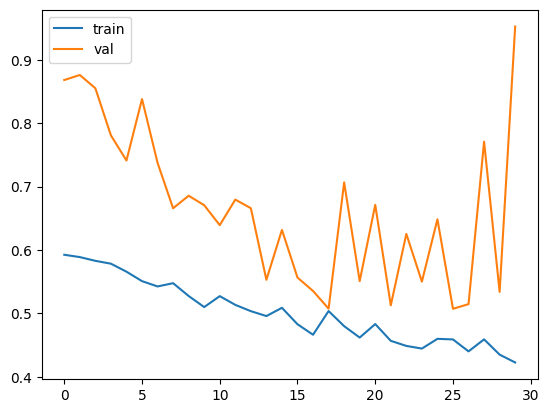

In [41]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

In [42]:
import numpy as np
for layer in model.layers:
    if isinstance(layer, Dense) or isinstance(layer, Conv2D):
        print(layer.name, np.min(layer.get_weights()[0]), np.max(layer.get_weights()[0]))

fe0 -0.111775205 0.10884713
fe1 -0.10969607 0.10802284
fe2 -0.08941605 0.081182644
fe3 -0.07745548 0.080955535
d1 -0.095573924 0.06642467
d2 -0.106258124 0.10643243


I changed Adam optimizer's learning rate to 0.0003 because "3e-4 is the best learning rate for Adam, hands down." - @karpathy on X, and trained for 30 epochs to see an improvement in validation loss. The model required more epochs to learn to handle the data augmentation we introduced.

# Transfer Learning

In this part of the lab, you will load VGG16 and try to get it to improve the result of this model.

When you use pretrained networks, you have to pay attention to the preprocessing requirements of the inputs.

For example, `Resnet50` requires a minimum of `(200, 200, 3)` image.  Since our cats and dogs example has an image size of `(150, 150, 3)`, one possible solution is to use `UpSampling2D` layer to increase the image to `(300, 300, 3)`.

```python
x = UpSampling2D(size=(2, 2))(x_input)
```

You should definitely read any pre-trained documentation before starting using it. For VGG16, you can find it at https://keras.io/api/applications/vgg/.

All frameworks come with several pretrained models, like VGG, MobileNet, ResNet, and GoogleNet.

In [12]:
from tensorflow.keras.applications import VGG16

vgg16 = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))

In [44]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
import numpy as np
for layer in vgg16.layers:
    if isinstance(layer, Dense) or isinstance(layer, Conv2D):
        print(layer.name, np.min(layer.get_weights()[0]), np.max(layer.get_weights()[0]))

block1_conv1 -0.67140007 0.6085159
block1_conv2 -0.21561293 0.28917095
block2_conv1 -0.33594823 0.41661108
block2_conv2 -0.18190438 0.27737573
block3_conv1 -0.18306334 0.5444108
block3_conv2 -0.17710502 0.45931634
block3_conv3 -0.17968427 0.39153737
block4_conv1 -0.124099575 0.31388226
block4_conv2 -0.10524698 0.33766
block4_conv3 -0.12739666 0.25623572
block5_conv1 -0.113298565 0.1904444
block5_conv2 -0.13681108 0.20515127
block5_conv3 -0.09288482 0.28699666


In [46]:
# every layer or model with trainable set to false does not
# update weights

vgg16.trainable = False

x_i = Input((150, 150, 3), name="input") # (4, 4, 512)
x = vgg16(x_i)
x = MaxPooling2D(2, 2)(x)
x = Flatten()(x)
x = Dropout(0.5, name="drop_input_512")(x)
x = Dense(512, name="d512", activation="relu")(x)
x = Dropout(0.5, name="drop_input_100")(x)
x = Dense(100, name="d100", activation="relu")(x)
x = Dense(1, name="d2", activation="sigmoid")(x)

model = Model(inputs=x_i, outputs=x)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input_512 (Dropout)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d512 (Dense)                    │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input_100 (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d100 (Dense)                    │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,815,177 (60.33 MB)

 Trainable params: 1,100,489 (4.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [47]:
new_model = Model(vgg16.inputs, vgg16.get_layer("block2_pool").output)
new_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,160 (1016.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 260,160 (1016.25 KB)

In [19]:
import glob

dataset_dir = "D:/ECEN521/"

train_dir = dataset_dir + "/train"

train_dogs = glob.glob(train_dir + "/dog*.*")
train_cats = glob.glob(train_dir + "/cat*.*")

sampled_train_dir = dataset_dir + "/s_train"
sampled_valid_dir = dataset_dir + "/s_valid"
sampled_test_dir = dataset_dir + "/s_test"

D:/ECEN521//train\dog.0.jpg
(1, 150, 150, 3) (1, 4, 4, 512)


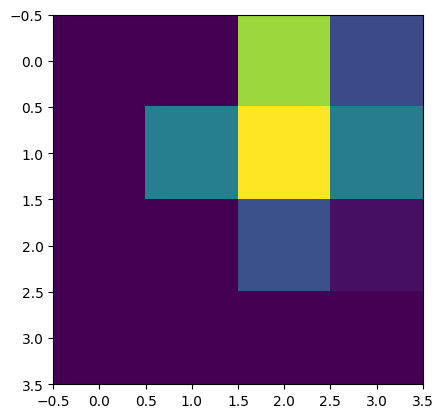

In [20]:
fname = train_dogs[0]
print(fname)
img = image.load_img(fname, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
output = vgg16(x)
print(x.shape, output.shape)
for i in range(3):
    plt.imshow(output[0][...,i])

Note that in this case, we are not retraining the VGG16 model, just the final dense layers. Why? <br>

The base has already learned the general features but the head needs to be optimized because it is identifying the fine grain details. It is also computationally cheaper and avoids overfitting. The head is where the model is truly recognizing what is unique to our classes.

In [50]:
optimizer = tf.keras.optimizers.SGD(0.001, momentum=0.9)

model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["acc"])

history = model.fit(
    train_generator,
    steps_per_epoch=2 * NSAMPLES//100, # number of times it executes until it declares epoch is over.
    epochs=10,
    validation_data=valid_generator,
    validation_steps=2 * NSAMPLES//(2*100))

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 646ms/step - acc: 0.5161 - loss: 0.8557 - val_acc: 0.6350 - val_loss: 0.6507
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - acc: 0.5385 - loss: 0.7610 - val_acc: 0.7080 - val_loss: 0.6117
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 544ms/step - acc: 0.5591 - loss: 0.7092 - val_acc: 0.7520 - val_loss: 0.5877
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 536ms/step - acc: 0.5989 - loss: 0.6679 - val_acc: 0.7700 - val_loss: 0.5685
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - acc: 0.6074 - loss: 0.6678 - val_acc: 0.7140 - val_loss: 0.5643
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 526ms/step - acc: 0.6178 - loss: 0.6508 - val_acc: 0.7650 - val_loss: 0.5443
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 542ms/step - acc: 0.6353 - loss: 0.6337 - val_acc: 0.7940 - val_loss: 0.5351
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 532ms/step - acc: 0.6495 - loss: 0.6263 - val_acc: 0.7760 - val_loss: 0.5207
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 524ms/

Now, you should change the model above so that the vgg16 is only run before, and you should store the features extracted by vgg16 in memory in order to train the last layers of the network.

### VGG 16 with Retrained Head

In [21]:
# Cache VGG16 features once, then train only the dense head.
# This avoids re-running VGG16 during every training step.

import os
import math
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Local paths (override by setting ECEN521_DATASET_DIR)
dataset_dir = os.environ.get("ECEN521_DATASET_DIR", "D:/ECEN521")
sampled_train_dir = os.path.join(dataset_dir, "s_train")
sampled_valid_dir = os.path.join(dataset_dir, "s_valid")

# Frozen VGG16 conv base
vgg16_frozen = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
vgg16_frozen.trainable = False

# IMPORTANT: caching requires a deterministic pipeline (no augmentation, no shuffle)
extract_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_extract_gen = extract_datagen.flow_from_directory(
    sampled_train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode="binary",
    shuffle=False,
)

valid_extract_gen = extract_datagen.flow_from_directory(
    sampled_valid_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode="binary",
    shuffle=False,
)

train_extract_gen.reset()
valid_extract_gen.reset()

train_features = vgg16_frozen.predict(
    train_extract_gen,
    steps=math.ceil(train_extract_gen.samples / train_extract_gen.batch_size),
    verbose=1,
)
valid_features = vgg16_frozen.predict(
    valid_extract_gen,
    steps=math.ceil(valid_extract_gen.samples / valid_extract_gen.batch_size),
    verbose=1,
)

train_labels = train_extract_gen.classes
valid_labels = valid_extract_gen.classes

print("train_features:", train_features.shape, "train_labels:", train_labels.shape)
print("valid_features:", valid_features.shape, "valid_labels:", valid_labels.shape)

# Optional: persist to disk for quick reload
# np.save("vgg16_train_features.npy", train_features)
# np.save("vgg16_train_labels.npy", train_labels)
# np.save("vgg16_valid_features.npy", valid_features)
# np.save("vgg16_valid_labels.npy", valid_labels)

from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

feat_in = Input(shape=train_features.shape[1:], name="vgg16_features")
x = GlobalAveragePooling2D()(feat_in)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
out = Dense(1, activation="sigmoid")(x)

feature_head = Model(feat_in, out, name="vgg16_feature_head")
feature_head.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["acc"],
)
feature_head.summary()

history_feature_head = feature_head.fit(
    train_features,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(valid_features, valid_labels),
    shuffle=True,
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step
train_features: (2000, 4, 4, 512) train_labels: (2000,)
valid_features: (1000, 4, 4, 512) valid_labels: (1000,)


Model: "vgg16_feature_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16_features (InputLayer)          │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,585 (514.00 KB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.6910 - loss: 4.6421 - val_acc: 0.9260 - val_loss: 0.3547
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8405 - loss: 2.0831 - val_acc: 0.9510 - val_loss: 0.2678
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8745 - loss: 1.5286 - val_acc: 0.9560 - val_loss: 0.2505
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8810 - loss: 1.3445 - val_acc: 0.9550 - val_loss: 0.2370
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9030 - loss: 1.1082 - val_acc: 0.9590 - val_loss: 0.2444
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9105 - loss: 0.9952 - val_acc: 0.9600 - val_loss: 0.2550
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.8990 - loss: 1.0086 - val_acc: 0.9500 - val_loss: 0.2578
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9100 - loss: 0.8290 - val_acc: 0.9540 - val_loss: 0.2477
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9160

In Keras, you can set "trainable" attribute for any layer or model. You should traverse vgg16, and try to set the trainable parameter to False before block5, and from block5 forward, it should be set to True.

In [52]:
vgg16 = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))

for l in vgg16.layers:
    if 'block5' not in l.name:
        l.trainable = False
        print(f'not training layer {l.name}')
    else:
        print(f'training layer {l.name}')

x_i = Input((150, 150, 3), name="input")
x = vgg16(x_i)
x = MaxPooling2D(2, 2)(x)
x = Flatten()(x)
x = Dropout(0.5, name="drop_input_512")(x)
x = Dense(512, name="d512", activation="relu")(x)
x = Dropout(0.5, name="drop_input_100")(x)
x = Dense(100, name="d100", activation="relu")(x)
x = Dense(1, name="d2", activation="sigmoid")(x)

model = Model(inputs=x_i, outputs=x)
model.summary()

not training layer input_layer_2
not training layer block1_conv1
not training layer block1_conv2
not training layer block1_pool
not training layer block2_conv1
not training layer block2_conv2
not training layer block2_pool
not training layer block3_conv1
not training layer block3_conv2
not training layer block3_conv3
not training layer block3_pool
not training layer block4_conv1
not training layer block4_conv2
not training layer block4_conv3
not training layer block4_pool
training layer block5_conv1
training layer block5_conv2
training layer block5_conv3
training layer block5_pool


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input_512 (Dropout)        │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d512 (Dense)                    │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input_100 (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d100 (Dense)                    │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,815,177 (60.33 MB)

 Trainable params: 8,179,913 (31.20 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

### Training the Model

In [22]:
# Fine-tune VGG16: freeze blocks 1-4, train block5 + dense head.

import os
import math
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.models import Model

# Local paths (override by setting ECEN521_DATASET_DIR)
dataset_dir = os.environ.get("ECEN521_DATASET_DIR", "D:/ECEN521")
sampled_train_dir = os.path.join(dataset_dir, "s_train")
sampled_valid_dir = os.path.join(dataset_dir, "s_valid")

# Build model
vgg16 = VGG16(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
for l in vgg16.layers:
    l.trainable = ("block5" in l.name)

x_i = Input((150, 150, 3), name="input")
x = vgg16(x_i)
x = MaxPooling2D(2, 2)(x)
x = Flatten()(x)
x = Dropout(0.5, name="drop_input_512")(x)
x = Dense(512, name="d512", activation="relu")(x)
x = Dropout(0.5, name="drop_input_100")(x)
x = Dense(100, name="d100", activation="relu")(x)
x = Dense(1, name="d2", activation="sigmoid")(x)

model = Model(inputs=x_i, outputs=x)
model.summary()

# Data pipeline (correct preprocessing)
train_datagen_vgg_ft = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
valid_datagen_vgg_ft = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_vgg_ft = train_datagen_vgg_ft.flow_from_directory(
    sampled_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
)
valid_generator_vgg_ft = valid_datagen_vgg_ft.flow_from_directory(
    sampled_valid_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

steps_per_epoch = max(1, math.ceil(train_generator_vgg_ft.samples / train_generator_vgg_ft.batch_size))
validation_steps = max(1, math.ceil(valid_generator_vgg_ft.samples / valid_generator_vgg_ft.batch_size))

optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["acc"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_vgg_finetune = model.fit(
    train_generator_vgg_ft,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator_vgg_ft,
    validation_steps=validation_steps,
    callbacks=callbacks,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_input_512 (Dropout)             │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ d512 (Dense)                         │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_input_100 (Dropout)             │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ d100 (Dense)                         │ (None, 100)                 │          51,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ d2 (Dense)                           │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,815,177 (60.33 MB)

 Trainable params: 8,179,913 (31.20 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - acc: 0.6895 - loss: 2.3643 - val_acc: 0.8810 - val_loss: 0.2704 - learning_rate: 1.0000e-04
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - acc: 0.8100 - loss: 0.4083 - val_acc: 0.9000 - val_loss: 0.2173 - learning_rate: 1.0000e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - acc: 0.8555 - loss: 0.3231 - val_acc: 0.9050 - val_loss: 0.2184 - learning_rate: 1.0000e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - acc: 0.8740 - loss: 0.3004 - val_acc: 0.9230 - val_loss: 0.1629 - learning_rate: 1.0000e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - acc: 0.8770 - loss: 0.2634 - val_acc: 0.9320 - val_loss: 0.1633 - learning_rate: 1.0000e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - acc: 0.8885 - loss: 0.2872 - val_acc: 0.9230 - val_loss: 0.2617 - learning_rate: 1.0000e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/

You should also try to use resnet50 and mobilenetv2.  You will need to use the appropriate `preprocess_function` function for each of the networks.

Remember also that for resnet50, you need to use an image of `(300, 300, 3)` and to use `UpSampling2D` before invoking resnet50 block.

The documentations can be found at https://keras.io/api/applications/

Report the best results you obtained, and plot the loss and accuracy of your experiments.

In [23]:
# ResNet50 transfer learning (with correct preprocessing)
# Note: ResNet50 expects a larger input; we upsample 150->300 inside the model.

import os
import math
import tensorflow as tf

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, UpSampling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Local paths (override by setting ECEN521_DATASET_DIR)
dataset_dir = os.environ.get("ECEN521_DATASET_DIR", "D:/ECEN521")
sampled_train_dir = os.path.join(dataset_dir, "s_train")
sampled_valid_dir = os.path.join(dataset_dir, "s_valid")

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
valid_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess_input)

data_train_resnet = train_datagen_resnet.flow_from_directory(
    sampled_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
)

data_valid_resnet = valid_datagen_resnet.flow_from_directory(
    sampled_valid_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

steps_per_epoch = max(1, math.ceil(data_train_resnet.samples / data_train_resnet.batch_size))
validation_steps = max(1, math.ceil(data_valid_resnet.samples / data_valid_resnet.batch_size))

base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(300, 300, 3))
base_resnet.trainable = False

x_i = Input((150, 150, 3), name="input")
x = UpSampling2D(size=(2, 2), interpolation="bilinear")(x_i)  # (300, 300, 3)
x = base_resnet(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
out = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=x_i, outputs=out, name="resnet50_transfer")
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["acc"],
)
resnet_model.summary()

callbacks_resnet = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_resnet = resnet_model.fit(
    data_train_resnet,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=data_valid_resnet,
    validation_steps=validation_steps,
    callbacks=callbacks_resnet,
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 300, 300, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 10, 10, 2048)        │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 294s 4s/step - acc: 0.8960 - loss: 0.2434 - val_acc: 0.9710 - val_loss: 0.0782 - learning_rate: 3.0000e-04
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - acc: 0.9700 - loss: 0.0863 - val_acc: 0.9830 - val_loss: 0.0560 - learning_rate: 3.0000e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - acc: 0.9745 - loss: 0.0601 - val_acc: 0.9840 - val_loss: 0.0511 - learning_rate: 3.0000e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 242s 4s/step - acc: 0.9855 - loss: 0.0509 - val_acc: 0.9860 - val_loss: 0.0509 - learning_rate: 3.0000e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - acc: 0.9825 - loss: 0.0484 - val_acc: 0.9770 - val_loss: 0.0542 - learning_rate: 3.0000e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - acc: 0.9870 - loss: 0.0381 - val_acc: 0.9730 - val_loss: 0.0631 - learning_rate: 3.0000e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - acc: 0.9900 - loss: 0.0339 - val_acc: 0.9840 - val_loss: 0.0472 - learning_ra

In [ ]:
# MobileNetV2 transfer learning (with correct preprocessing)

import os
import math
import tensorflow as tf

from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input as mobilenet_preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Local paths (override by setting ECEN521_DATASET_DIR)
dataset_dir = os.environ.get("ECEN521_DATASET_DIR", "D:/ECEN521")
sampled_train_dir = os.path.join(dataset_dir, "s_train")
sampled_valid_dir = os.path.join(dataset_dir, "s_valid")

train_datagen_mnet = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
valid_datagen_mnet = ImageDataGenerator(preprocessing_function=mobilenet_preprocess_input)

data_train_mnet = train_datagen_mnet.flow_from_directory(
    sampled_train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
)

data_valid_mnet = valid_datagen_mnet.flow_from_directory(
    sampled_valid_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

steps_per_epoch = max(1, math.ceil(data_train_mnet.samples / data_train_mnet.batch_size))
validation_steps = max(1, math.ceil(data_valid_mnet.samples / data_valid_mnet.batch_size))

base_mnet = MobileNetV2(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
base_mnet.trainable = False

x_i = Input((150, 150, 3), name="input")
x = base_mnet(x_i, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
out = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs=x_i, outputs=out, name="mobilenetv2_transfer")
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["acc"],
)
mobilenet_model.summary()

callbacks_mnet = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
]

history_mobilenet = mobilenet_model.fit(
    data_train_mnet,
    epochs=10,
    steps_per_epoch=steps_per_epoch,
    validation_data=data_valid_mnet,
    validation_steps=validation_steps,
    callbacks=callbacks_mnet,
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


C:\Users\Jaxba\AppData\Local\Temp\ipykernel_29796\2036316102.py:45: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mnet = MobileNetV2(weights="imagenet", include_top=False, input_shape=(150, 150, 3))


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
44/63 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - acc: 0.7728 - loss: 0.4332

# Hyperparameter Tuning Using KerasTuner (AutoML)

In this lab, you will perform hyperparameter tuning using KerasTuner.

You will fine tune a model to try to outperform other models.

To install keras tuner, you need to do.

```shell
pip3 install keras-tuner
```

In [56]:
# you may need to uninstall and reinstall protobuffer to get the latest version of keras tuner.

#!yes | pip3 uninstall protobuf python3-protobuf
#!pip3 install --upgrade protobuf
!pip3 install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 20.4 MB/s eta 0:00:00


In [57]:
from tensorflow import keras
import keras_tuner as kt

(img_train, label_train), (img_test, label_test) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values between 0 and 1
img_train = img_train.astype('float32') / 255.0
img_test = img_test.astype('float32') / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


(28, 28)


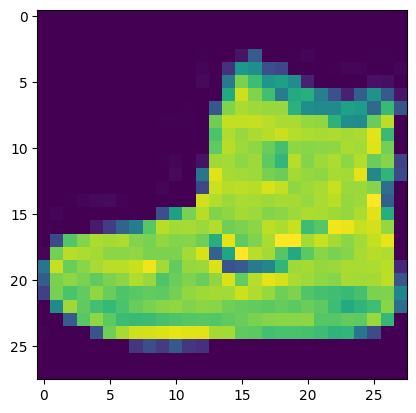

In [58]:
print(img_train[0].shape)
plt.imshow(img_train[0].reshape(28,28,1))

In [59]:
import tensorflow as tf

def model_builder(hp):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))

  # Tune the number of units in the first Dense layer
  # Choose an optimal value between 32-512

  # 8 x 6 x 3 x 3 ~ 500 options

  for i in range(hp.Int('layers', 3, 10)):
        model.add(tf.keras.layers.Dense(
            units=hp.Int('units_' + str(i), 50, 100, step=10),
            activation=hp.Choice('act_' + str(i), ['relu', 'swish', 'gelu'])))
  model.add(keras.layers.Dense(10))

  # Tune the learning rate for the optimizer
  # Choose an optimal value from 0.01, 0.001, or 0.0001
  hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

  model.compile(optimizer = keras.optimizers.Adam(learning_rate = hp_learning_rate),
                loss = keras.losses.SparseCategoricalCrossentropy(from_logits = True),
                metrics = ['accuracy'])

  return model

In [60]:
mode = 'random'
keras_tuner_dir = 'kt_dir'

try:
    shutil.rmtree(keras_tuner_dir)
except:
    pass

if mode == 'hyperband':
    tuner = kt.Hyperband(
        model_builder,
        objective = 'val_accuracy',
        max_epochs = 10,
        factor = 3,
        directory = keras_tuner_dir,
        project_name = 'intro_to_kt_hyperband')
else:
    tuner = kt.RandomSearch(
        model_builder,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory=keras_tuner_dir,
        project_name='intro_kt_random')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
tuner.search(
    img_train, label_train,
    batch_size=64,
    epochs = 5,
    validation_data = (img_test, label_test),
    callbacks = [])

Trial 10 Complete [00h 00m 18s]
val_accuracy: 0.8669000267982483

Best val_accuracy So Far: 0.8744000196456909
Total elapsed time: 00h 02m 49s


In [62]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

n_layers = best_hps.get('layers')
print(n_layers)
print()
for i in range(n_layers):
    print(best_hps.get('units_' + str(i)), best_hps.get('act_' + str(i)))
print(best_hps.get('learning_rate'))

6

60 relu
100 relu
80 relu
90 relu
60 swish
60 relu
0.001


Keras tuner has three optimizers.

- RandomSearch
- BayesianOptimization (Gaussian Processes)
- Hyperband

In the code, we showed how to start random search and hyperband.

Usually, you use the following parameters in Keras Tuner.

- hp.Boolean
- hp.Int
- hp.Float
- hp.Choice
- hp.Fixed
- hp.Float
- Conditional scope

You can find more information in https://keras.io/keras_tuner/

In [62]:
# Helper: plot training curves for any History object

import matplotlib.pyplot as plt


def plot_history(history, title=None):
    if history is None:
        print("No history to plot")
        return

    h = history.history
    title = title or "Training"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(h.get("loss", []), label="train")
    if "val_loss" in h:
        axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    # Accuracy
    acc_key = "acc" if "acc" in h else ("accuracy" if "accuracy" in h else None)
    if acc_key is not None:
        axes[1].plot(h.get(acc_key, []), label="train")
        val_acc_key = f"val_{acc_key}"
        if val_acc_key in h:
            axes[1].plot(h[val_acc_key], label="val")
        axes[1].set_title(f"{title} - Accuracy")
        axes[1].set_xlabel("epoch")
        axes[1].legend()
    else:
        axes[1].axis("off")
        axes[1].set_title(f"{title} - (no accuracy metric)")

    plt.tight_layout()
    plt.show()


# Examples:
# plot_history(history_feature_head, "VGG16 cached features head")
# plot_history(history_vgg_finetune, "VGG16 fine-tune block5")
# plot_history(history_resnet, "ResNet50 transfer")
# plot_history(history_mobilenet, "MobileNetV2 transfer")